In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs Available:", gpus)

if not gpus:
    raise RuntimeError("GPU NOT detected. Enable GPU runtime.")

tf.config.experimental.set_memory_growth(gpus[0], True)

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split

NUM_CLASSES = 100
IMG_SIZE = 32
BATCH_SIZE = 64

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

y_train = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test, NUM_CLASSES)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

In [4]:
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))

train_ds = (
    train_ds
    .shuffle(5000)
    .map(lambda x, y: preprocess(data_augmentation(x), y), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(preprocess)
    .batch(BATCH_SIZE)
)

In [6]:
from tensorflow.keras import regularizers, initializers

base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
inputs = keras.Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    512,
    kernel_initializer=initializers.HeNormal(),
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [8]:
optimizer = keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        save_best_only=True
    )
]

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 83ms/step - accuracy: 0.1879 - loss: 3.7031 - val_accuracy: 0.3718 - val_loss: 2.5360 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.3049 - loss: 2.8845 - val_accuracy: 0.3974 - val_loss: 2.4365 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3251 - loss: 2.7872 - val_accuracy: 0.4128 - val_loss: 2.3896 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3437 - loss: 2.7201 - val_accuracy: 0.4158 - val_loss: 2.3782 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3520 - loss: 2.6802 - val_accuracy: 0.4276 - val_loss: 2.3548 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.3605 - loss: 2.6598 - val_accuracy: 0.4252 - val_loss: 2.3657 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3683 - l

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [12]:
model.compile(
    optimizer=keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 99ms/step - accuracy: 0.3476 - loss: 2.7800 - val_accuracy: 0.4014 - val_loss: 2.5076 - learning_rate: 1.0000e-05
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.3786 - loss: 2.5867 - val_accuracy: 0.4162 - val_loss: 2.4367 - learning_rate: 1.0000e-05
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.3971 - loss: 2.5056 - val_accuracy: 0.4278 - val_loss: 2.3918 - learning_rate: 1.0000e-05
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 73ms/step - accuracy: 0.4067 - loss: 2.4371 - val_accuracy: 0.4308 - val_loss: 2.3574 - learning_rate: 1.0000e-05
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.4166 - loss: 2.3925 - val_accuracy: 0.4392 - val_loss: 2.3309 - learning_rate: 1.0000e-05
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.4248 - loss: 2.3641 - val_accuracy: 0.4432 - val_loss: 2.3146 - learning_rate: 1.0000e-05
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/ste

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(np.concatenate([y for x, y in test_ds], axis=0), axis=1)

157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step


In [14]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.52      0.48      0.50       100
           2       0.39      0.32      0.35       100
           3       0.23      0.15      0.18       100
           4       0.24      0.21      0.22       100
           5       0.41      0.29      0.34       100
           6       0.47      0.47      0.47       100
           7       0.49      0.58      0.53       100
           8       0.42      0.55      0.47       100
           9       0.56      0.55      0.56       100
          10       0.40      0.34      0.37       100
          11       0.33      0.24      0.28       100
          12       0.53      0.47      0.50       100
          13       0.36      0.32      0.34       100
          14       0.36      0.36      0.36       100
          15       0.39      0.46      0.42       100
          16       0.50      0.56      0.53       100
          17       0.63    

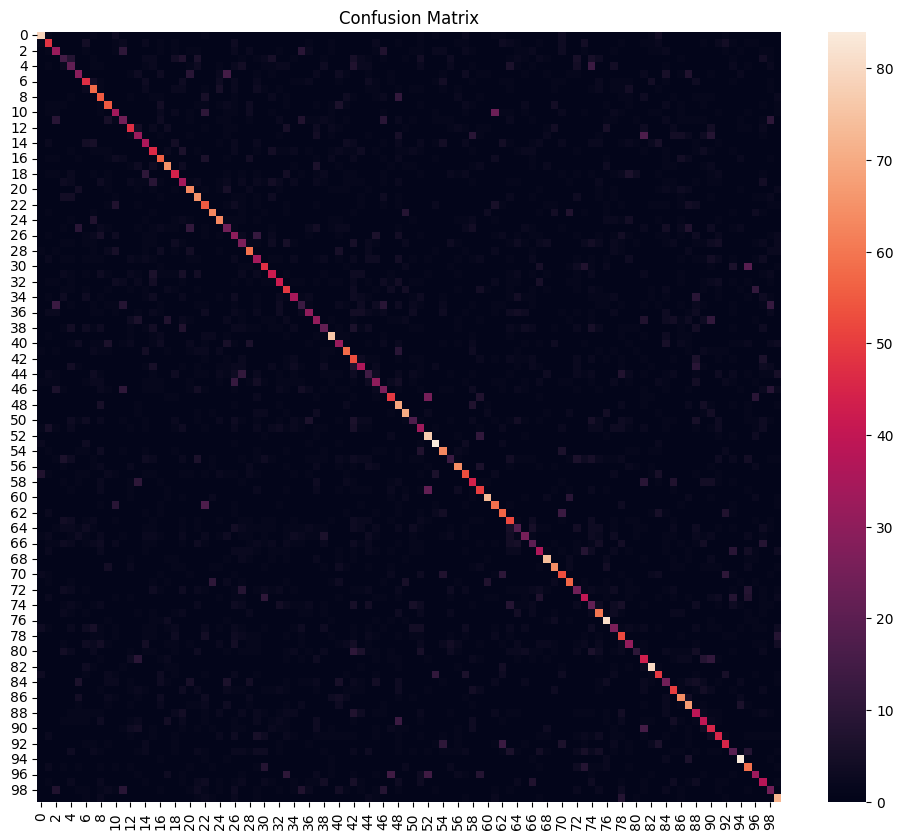

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm)
plt.title("Confusion Matrix")
plt.show()

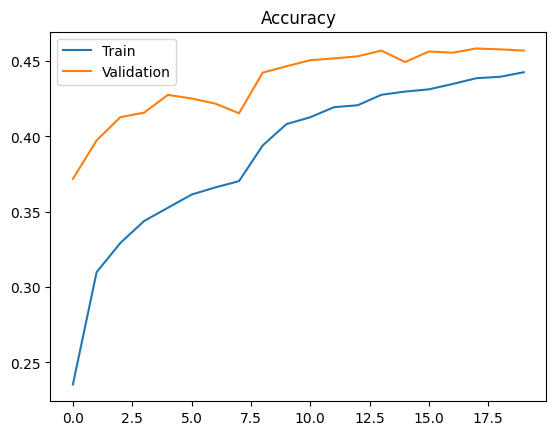

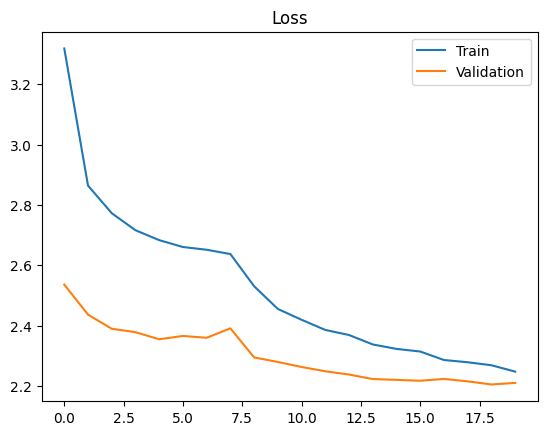

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()